# Sistema de Recomendadores de Películas

Este notebook implementa tres sistemas de recomendación de películas de complejidad creciente, utilizando el dataset Full MovieLens con ~45,000 películas.

**Dataset:** MovieLens (películas hasta julio de 2017)
**Técnicas:** Calificación ponderada IMDB · TF-IDF + Similitud Coseno · CountVectorizer + Metadata Soup

## Sección 1 — Configuración e Ingesta de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import linear_kernel, cosine_similarity

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

Cargamos el conjunto de datos principal con metadatos de ~45,000 películas.

In [2]:
df = pd.read_csv('./data/movies_metadata.csv', low_memory=False)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (45466, 24)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0


In [3]:
df[['vote_average', 'vote_count']].describe()

,vote_average,vote_count
count,45460.000000,45460.000000
mean,5.618207,109.897338
std,1.924216,491.310374
min,0.000000,0.000000
25%,5.000000,3.000000
50%,6.000000,10.000000
75%,6.800000,34.000000
max,10.000000,14075.000000


### Distribución de calificaciones y número de votos

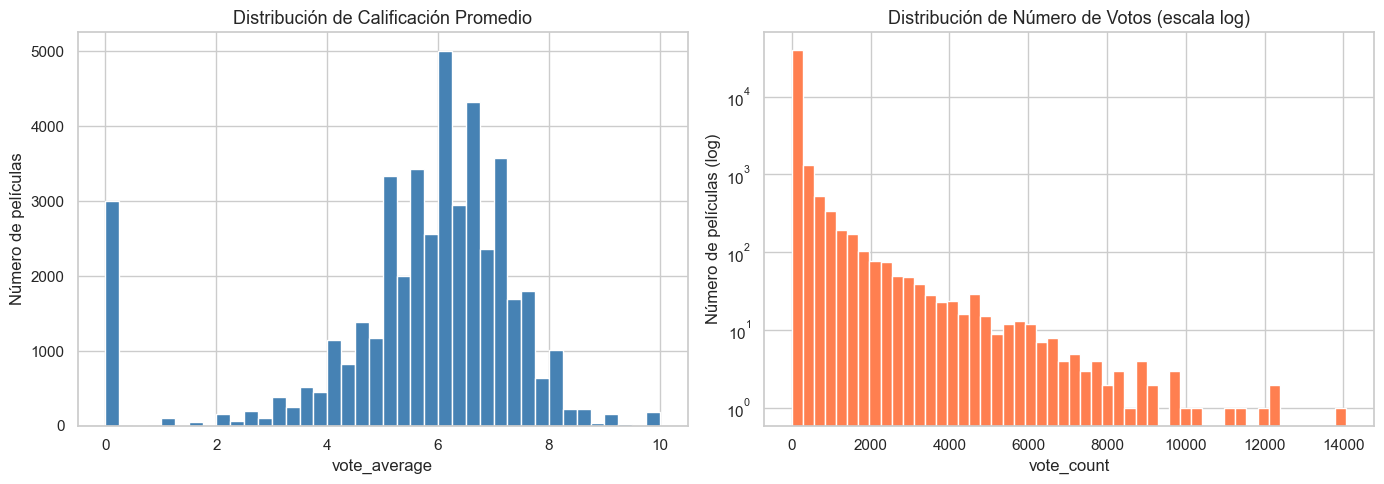

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de vote_average
axes[0].hist(pd.to_numeric(df['vote_average'], errors='coerce').dropna(),
             bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Calificación Promedio', fontsize=13)
axes[0].set_xlabel('vote_average')
axes[0].set_ylabel('Número de películas')

# Histograma de vote_count en escala log
vote_counts = pd.to_numeric(df['vote_count'], errors='coerce').dropna()
axes[1].hist(vote_counts[vote_counts > 0], bins=50, color='coral', edgecolor='white', log=True)
axes[1].set_title('Distribución de Número de Votos (escala log)', fontsize=13)
axes[1].set_xlabel('vote_count')
axes[1].set_ylabel('Número de películas (log)')

plt.tight_layout()
plt.show()

## Sección 2 — Recomendador por Calificación Ponderada (Estilo IMDB Top 250)

El primer sistema de recomendación es el más simple: ordenar las películas por una calificación ponderada que toma en cuenta tanto la calificación promedio como el número de votos.

Usamos la fórmula del **Top 250 de IMDB**:

$$\text{WR} = \frac{v}{v + m} \cdot R + \frac{m}{v + m} \cdot C$$

Donde:
- **v** = número de votos de la película (`vote_count`)
- **m** = umbral mínimo de votos (percentil 90)
- **R** = calificación promedio de la película (`vote_average`)
- **C** = media global de calificaciones en todo el conjunto de datos

### Calcular C y m

**C** es la calificación media de todas las películas. **m** es el percentil 90 del número de votos, que actúa como filtro: solo películas con más votos que el 90% de las demás entran en la lista.

In [5]:
# Convertir columnas numéricas (pueden contener strings no válidos)
df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce')
df['vote_count'] = pd.to_numeric(df['vote_count'], errors='coerce')

C = df['vote_average'].mean()
m = df['vote_count'].quantile(0.90)

print(f'C (calificación media global): {C:.4f}')
print(f'm (percentil 90 de votos):     {m:.1f}')

C (calificación media global): 5.6182
m (percentil 90 de votos):     160.0


In [6]:
q_movies = df.copy().loc[df['vote_count'] >= m]
print(f'Shape df original:  {df.shape}')
print(f'Shape q_movies:     {q_movies.shape}')
print(f'Películas calificadas: {len(q_movies)} ({len(q_movies)/len(df)*100:.1f}% del total)')

Shape df original:  (45466, 24)
Shape q_movies:     (4555, 24)
Películas calificadas: 4555 (10.0% del total)


In [7]:
def weighted_rating(x, m=m, C=C):
    v = x['vote_count']
    R = x['vote_average']
    return (v / (v + m) * R) + (m / (m + v) * C)

q_movies['score'] = q_movies.apply(weighted_rating, axis=1)
q_movies = q_movies.sort_values('score', ascending=False)

q_movies[['title', 'vote_count', 'vote_average', 'score']].head(15)

,title,vote_count,vote_average,score
314,The Shawshank Redemption,8358.0,8.5,8.445869
834,The Godfather,6024.0,8.5,8.425439
10309,Dilwale Dulhania Le Jayenge,661.0,9.1,8.421453
12481,The Dark Knight,12269.0,8.3,8.265477
2843,Fight Club,9678.0,8.3,8.256385
292,Pulp Fiction,8670.0,8.3,8.251406
522,Schindler's List,4436.0,8.3,8.206639
23673,Whiplash,4376.0,8.3,8.205404
5481,Spirited Away,3968.0,8.3,8.196055
2211,Life Is Beautiful,3643.0,8.3,8.187171


### Top 15 películas por calificación ponderada

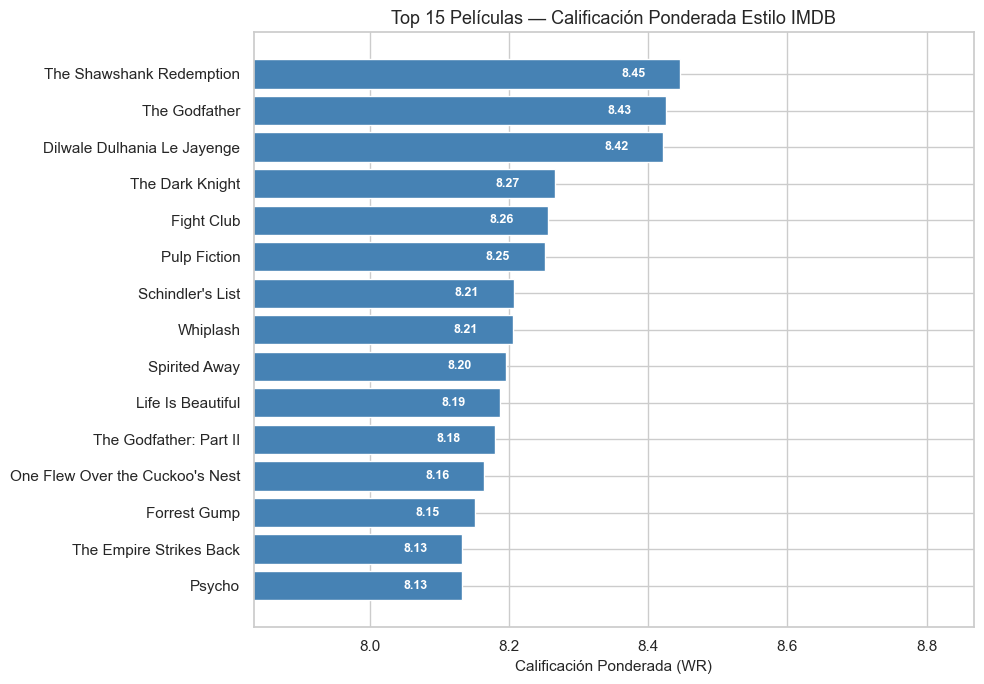

In [8]:
top15 = q_movies[['title', 'score']].head(15).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15['title'][::-1], top15['score'][::-1], color='steelblue', edgecolor='white')

for bar, val in zip(bars, top15['score'][::-1]):
    ax.text(bar.get_width() - 0.05, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', ha='right', va='center', color='white', fontweight='bold', fontsize=9)

ax.set_xlabel('Calificación Ponderada (WR)', fontsize=11)
ax.set_title('Top 15 Películas — Calificación Ponderada Estilo IMDB', fontsize=13)
ax.set_xlim(left=top15['score'].min() - 0.3)
plt.tight_layout()
plt.show()

## Sección 3 — Recomendador Basado en Contenido (Sinopsis · TF-IDF)

Ahora construiremos un sistema que recomienda películas **similares a una dada**, basándose en la similitud de sus sinopsis.

### ¿Qué es TF-IDF?

**TF-IDF** (Frecuencia de Término × Inversa de Frecuencia de Documento) convierte texto en vectores numéricos. Le da más peso a palabras específicas de una película y menos peso a palabras comunes que aparecen en muchas sinopsis (como "man", "family", etc.).

### ¿Qué es la Similitud Coseno?

Mide el ángulo entre dos vectores de palabras. Dos películas con descripción similar tendrán un ángulo cercano a cero → similitud coseno cercana a 1.

$$\cos(x,y) = \frac{x \cdot y}{\|x\| \cdot \|y\|}$$

Usamos `linear_kernel` en lugar de `cosine_similarity` porque con vectores TF-IDF normalizados el producto punto equivale a la similitud coseno, y es más rápido.

In [9]:
# Rellenar NaN en overview con cadena vacía
df['overview'] = df['overview'].fillna('')

# Construir matriz TF-IDF
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['overview'])

print(f'Shape de la matriz TF-IDF: {tfidf_matrix.shape}')
print(f'Primeras 10 palabras del vocabulario:')
print(tfidf.get_feature_names_out()[5000:5010])

Shape de la matriz TF-IDF: (45466, 75827)
Primeras 10 palabras del vocabulario:
['avails' 'avaks' 'avalanche' 'avalanches' 'avallone' 'avalon' 'avant'
 'avanthika' 'avanti' 'avaracious']


**Nota:** El cálculo de la matriz coseno (45466×45466) puede tardar 1–3 minutos dependiendo del hardware.

In [10]:
# Calcular matriz de similitud coseno (puede tardar unos minutos)
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
print(f'Shape de cosine_sim: {cosine_sim.shape}')

Shape de cosine_sim: (45466, 45466)


In [11]:
# Mapeo inverso: título → índice en el DataFrame
indices = pd.Series(df.index, index=df['title']).drop_duplicates()
indices[:5]

title
Toy Story                      0
Jumanji                        1
Grumpier Old Men               2
Waiting to Exhale              3
Father of the Bride Part II    4
dtype: int64

In [12]:
def get_recommendations(title, cosine_sim=cosine_sim):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    return df['title'].iloc[movie_indices]

### Demo: recomendaciones para *The Dark Knight Rises*

In [13]:
get_recommendations('The Dark Knight Rises')

12481                                      The Dark Knight
150                                         Batman Forever
1328                                        Batman Returns
15511                           Batman: Under the Red Hood
585                                                 Batman
21194    Batman Unmasked: The Psychology of the Dark Kn...
9230                    Batman Beyond: Return of the Joker
18035                                     Batman: Year One
19792              Batman: The Dark Knight Returns, Part 1
3095                          Batman: Mask of the Phantasm
Name: title, dtype: object

### Demo: recomendaciones para *The Godfather*

In [14]:
get_recommendations('The Godfather')

1178               The Godfather: Part II
44030    The Godfather Trilogy: 1972-1990
1914              The Godfather: Part III
23126                          Blood Ties
11297                    Household Saints
34717                   Start Liquidation
10821                            Election
38030            A Mother Should Be Loved
17729                   Short Sharp Shock
26293                  Beck 28 - Familjen
Name: title, dtype: object

### Limitaciones del recomendador por sinopsis

Observamos que *The Dark Knight Rises* devuelve casi exclusivamente otras películas de Batman. Lo ideal sería recomendar otras obras de **Christopher Nolan** (director), pero la sinopsis no captura esa información.

Para mejorar la calidad necesitamos metadatos más ricos: **director, actores principales y palabras clave de la trama**. Eso es exactamente lo que haremos en la Sección 4.

## Sección 4 — Recomendador Mejorado (Metadata Soup)

En esta sección construiremos un recomendador que usa:

- Los **3 actores principales**
- El **director**
- Los **géneros**
- Las **palabras clave** de la trama

Para esto necesitamos el archivo `data/credits.csv`. Si no lo tienes, descárgalo del Full MovieLens Dataset en Kaggle antes de continuar.

In [15]:
import os

credits_path = './data/credits.csv'
if not os.path.exists(credits_path):
    raise FileNotFoundError(
        "No se encontró data/credits.csv. "
        "Descárgalo del Full MovieLens Dataset en Kaggle y colócalo en la carpeta data/."
    )

print("credits.csv encontrado. Continuando...")

credits.csv encontrado. Continuando...


### 4.1 Cargar datos adicionales y hacer merge

In [16]:
# Cargar conjuntos de datos adicionales
credits = pd.read_csv('./data/credits.csv')
keywords = pd.read_csv('./data/keywords.csv')

# Recargar df limpio para esta sección
df2 = pd.read_csv('./data/movies_metadata.csv', low_memory=False)

# Eliminar filas con IDs no numéricos
df2 = df2[pd.to_numeric(df2['id'], errors='coerce').notna()].copy()

# Convertir id a entero en los tres DataFrames
keywords['id'] = keywords['id'].astype('int')
credits['id'] = credits['id'].astype('int')
df2['id'] = df2['id'].astype('int')

# Merge
df2 = df2.merge(credits, on='id')
df2 = df2.merge(keywords, on='id')

print(f'Shape después del merge: {df2.shape}')
df2[['title', 'cast', 'crew', 'keywords', 'genres']].head(2)

Shape después del merge: (46628, 27)


,title,cast,crew,keywords,genres
0,Toy Story,"[{'cast_id': 14, 'character': 'Woody (voice)',...","[{'credit_id': '52fe4284c3a36847f8024f49', 'de...","[{'id': 931, 'name': 'jealousy'}, {'id': 4290,...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '..."
1,Jumanji,"[{'cast_id': 1, 'character': 'Alan Parrish', '...","[{'credit_id': '52fe44bfc3a36847f80a7cd1', 'de...","[{'id': 10090, 'name': 'board game'}, {'id': 1...","[{'id': 12, 'name': 'Adventure'}, {'id': 14, '..."


### 4.2 Parsear columnas serializadas

Nuestros datos están presentes en forma de listas "serializadas" como cadenas de texto. Necesitamos convertirlas a un formato útil usando `ast.literal_eval`.

In [17]:
features = ['cast', 'crew', 'keywords', 'genres']
for feature in features:
    df2[feature] = df2[feature].apply(literal_eval)

### 4.3 Extraer director y top 3 actores/keywords/géneros

A partir de nuestras nuevas características —elenco, equipo y palabras clave—, necesitamos extraer los tres actores más importantes, el director y las palabras clave asociadas con esa película.

In [18]:
def get_director(x):
    for i in x:
        if i['job'] == 'Director':
            return i['name']
    return np.nan


def get_list(x):
    if isinstance(x, list):
        names = [i['name'] for i in x]
        # Checar si existen más de 3 elementos. Si sí, regresar primeros 3, si no, todos
        if len(names) > 3:
            names = names[:3]
        return names
    # regresar lista vacía si los datos no están bien formateados
    return []


# Extraer director de columnas crew
df2['director'] = df2['crew'].apply(get_director)

# Extraer top 3 de elenco, palabras clave y géneros
features = ['cast', 'keywords', 'genres']
for feature in features:
    df2[feature] = df2[feature].apply(get_list)

df2[['title', 'cast', 'director', 'keywords', 'genres']].head(3)

,title,cast,director,keywords,genres
0,Toy Story,"[Tom Hanks, Tim Allen, Don Rickles]",John Lasseter,"[jealousy, toy, boy]","[Animation, Comedy, Family]"
1,Jumanji,"[Robin Williams, Jonathan Hyde, Kirsten Dunst]",Joe Johnston,"[board game, disappearance, based on children'...","[Adventure, Fantasy, Family]"
2,Grumpier Old Men,"[Walter Matthau, Jack Lemmon, Ann-Margret]",Howard Deutch,"[fishing, best friend, duringcreditsstinger]","[Romance, Comedy]"


### 4.4 Continúa pre-procesamiento

El siguiente paso será convertir los textos a minúsculas y eliminar todos los espacios entre ellos.

Eliminar los espacios entre las palabras es un paso importante de preprocesamiento. Se hace para que nuestro vectorizador no cuente el "Johnny" de "Johnny Depp" y "Johnny Galecki" como el mismo. Después de este paso de procesamiento, los actores mencionados se representarán como "johnnydepp" y "johnnygalecki", y serán distintos para nuestro vectorizador.

Otro buen ejemplo en el que el modelo podría generar la misma representación vectorial es "bread jam" y "traffic jam". Por lo tanto, es mejor eliminar cualquier espacio presente.

In [19]:
def clean_data(x):
    if isinstance(x, list):
        return [str.lower(i.replace(" ", "")) for i in x]
    else:
        # Checar si existe el director. Si no, regresar ""
        if isinstance(x, str):
            return str.lower(x.replace(" ", ""))
        else:
            return ''


features = ['cast', 'keywords', 'director', 'genres']
for feature in features:
    df2[feature] = df2[feature].apply(clean_data)

### 4.5 Construir la Metadata Soup

Ahora estamos en posición de crear nuestra **metadata soup**: una cadena que contiene todos los metadatos que queremos alimentar a nuestro vectorizador (actores, director, géneros y palabras clave).

In [20]:
def create_soup(x):
    return ' '.join(x['keywords']) + ' ' + ' '.join(x['cast']) + ' ' + x['director'] + ' ' + ' '.join(x['genres'])


df2['soup'] = df2.apply(create_soup, axis=1)
df2[['soup']].head(2)

,soup
0,jealousy toy boy tomhanks timallen donrickles ...
1,boardgame disappearance basedonchildren'sbook ...


### 4.6 Vectorizar con CountVectorizer

Usamos **CountVectorizer** en lugar de TF-IDF. Esto se debe a que no queremos reducir el peso de la presencia de un actor o director si ha actuado o dirigido en relativamente más películas. No tiene mucho sentido intuitivo reducir su peso en este contexto.

La principal diferencia entre CountVectorizer y TF-IDF es el componente de Frecuencia Inversa de Documentos (IDF), que está presente en TF-IDF pero **no** en CountVectorizer.

**Nota:** El cálculo de `cosine_similarity` sobre el dataset completo puede tardar 1–3 minutos y requiere memoria disponible considerable.

In [21]:
count = CountVectorizer(stop_words='english')
count_matrix = count.fit_transform(df2['soup'])
print(f'Shape count_matrix: {count_matrix.shape}')

cosine_sim2 = cosine_similarity(count_matrix, count_matrix)

# Reconstruir índice inverso con el nuevo DataFrame
df2 = df2.reset_index(drop=True)
indices2 = pd.Series(df2.index, index=df2['title']).drop_duplicates()

Shape count_matrix: (46628, 73881)


### 4.7 Demos — Comparando recomendadores

> **Nota:** Esta sección requiere que la Sección 3 haya sido ejecutada primero (necesita `cosine_sim`, `indices` y `get_recommendations` en memoria).

In [22]:
def get_recommendations2(title, cosine_sim=cosine_sim2):
    idx = indices2[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    return df2['title'].iloc[movie_indices]

#### The Dark Knight Rises

In [23]:
print("=== Sección 3 (TF-IDF, sinopsis) ===")
print(get_recommendations('The Dark Knight Rises').tolist())
print()
print("=== Sección 4 (Metadata Soup) ===")
print(get_recommendations2('The Dark Knight Rises').tolist())

=== Sección 3 (TF-IDF, sinopsis) ===
['The Dark Knight', 'Batman Forever', 'Batman Returns', 'Batman: Under the Red Hood', 'Batman', 'Batman Unmasked: The Psychology of the Dark Knight', 'Batman Beyond: Return of the Joker', 'Batman: Year One', 'Batman: The Dark Knight Returns, Part 1', 'Batman: Mask of the Phantasm']

=== Sección 4 (Metadata Soup) ===
['The Dark Knight', 'Batman Begins', 'Shiner', 'Amongst Friends', 'Mitchell', 'Romeo Is Bleeding', 'The Prestige', 'Quicksand', 'Deadfall', 'Sara']


#### The Godfather

In [24]:
print("=== Sección 3 (TF-IDF, sinopsis) ===")
print(get_recommendations('The Godfather').tolist())
print()
print("=== Sección 4 (Metadata Soup) ===")
print(get_recommendations2('The Godfather').tolist())

=== Sección 3 (TF-IDF, sinopsis) ===
['The Godfather: Part II', 'The Godfather Trilogy: 1972-1990', 'The Godfather: Part III', 'Blood Ties', 'Household Saints', 'Start Liquidation', 'Election', 'A Mother Should Be Loved', 'Short Sharp Shock', 'Beck 28 - Familjen']

=== Sección 4 (Metadata Soup) ===


['The Godfather: Part III', 'The Godfather: Part II', 'The Rain People', 'Last Exit', 'Rege', "Manuscripts Don't Burn", "Manuscripts Don't Burn", 'The Night of the Following Day', 'The Son of No One', 'In the Name of the Law']


### Observaciones

El recomendador de Sección 4 tiene mejor desempeño porque captura:

- **Director:** *The Dark Knight Rises* ahora recomienda *The Prestige* y *Batman Begins* (Christopher Nolan)
- **Elenco compartido:** películas con los mismos actores principales suben en relevancia
- **Palabras clave de trama:** contexto temático más preciso

| | Sección 3 (TF-IDF) | Sección 4 (Metadata Soup) |
|---|---|---|
| **Datos** | Solo sinopsis | Director + actores + keywords + géneros |
| **Vectorizador** | TF-IDF | CountVectorizer |
| **Dark Knight Rises** | Solo películas de Batman | Batman + obras de Nolan |
| **The Godfather** | Temas temáticos similares | Familia Coppola + elenco compartido |

## Sección 5 — Conclusiones y Próximos Pasos

### Los tres sistemas construidos

| Sistema | Datos | Técnica | Complejidad | Calidad |
|---|---|---|---|---|
| **Sección 2** | vote_count, vote_average | Fórmula IMDB | Baja | Lista global, sin personalización |
| **Sección 3** | Sinopsis (overview) | TF-IDF + Similitud Coseno | Media | Temáticamente correcta pero limitada |
| **Sección 4** | Director, actores, keywords, géneros | CountVectorizer + Similitud Coseno | Alta | Captura estilo cinematográfico |

### Próximos pasos

Con este ejemplo podemos ver que un sistema de recomendación no necesariamente es complicado. Sin embargo, hay numerosas formas de mejorarlo:

1. **Filtro de popularidad:** tomar las 30 películas más similares, calcular calificación ponderada sobre ellas y devolver el top 10. Combina similitud con calidad.

2. **Más miembros del equipo:** incluir guionistas y productores en el soup aumenta la señal de "estilo de producción".

3. **Mayor peso al director:** mencionar al director múltiples veces en el soup eleva su influencia en el cálculo de similitud.

### Bonus: Esqueleto del Filtro de Popularidad

In [25]:
# Esqueleto del recomendador mejorado con filtro de popularidad
def get_recommendations_with_popularity(title, cosine_sim=cosine_sim2, top_n=30):
    idx = indices2[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Tomar las top_n más similares (en vez de solo 10)
    sim_scores = sim_scores[1:top_n + 1]
    movie_indices = [i[0] for i in sim_scores]

    # Extraer esas películas del DataFrame
    candidates = df2.iloc[movie_indices][['title', 'vote_count', 'vote_average']].copy()

    # Aplicar calificación ponderada sobre los candidatos
    # (reutilizar m y C calculados en Sección 2)
    # candidates['score'] = candidates.apply(weighted_rating, axis=1)
    # candidates = candidates.sort_values('score', ascending=False)

    # return candidates['title'].head(10)

    print("Películas candidatas (sin filtro de popularidad aún):")
    return candidates.head(10)

# get_recommendations_with_popularity('The Dark Knight Rises')
print("Descomentar las líneas anteriores para activar el filtro de popularidad.")

Descomentar las líneas anteriores para activar el filtro de popularidad.
